In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import xarray as xr
from numpy.typing import NDArray
from scipy.stats import distributions

In [ ]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR
    / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR
    / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
VEL_PATH = (
    DATA_DIR
    / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise.nc"
)

VELOCITY_VARIABLE = "cs"  # cs for cross-shelf with depth mean subtraced; cs_proj for cross-shelf projected by McCabe et al 2015

In [ ]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
velocity = xr.open_dataset(VEL_PATH)

# bit of a lazy way to use the cs_proj variable, since the notebook is set up for cs
if VELOCITY_VARIABLE == "cs_proj":
    velocity = velocity.drop_vars("cs").rename({"cs_proj": "cs"})

# resample midshelf nitrate to fill some of the gaps for composite calclulations
midshelf_nitrate = midshelf_nitrate.resample(time="1D").mean()

# interpolate velocity depths to match 1 meter bins in midshelf nitrate
velocity = velocity.interp(depth=midshelf_nitrate.depth)

# calculate monthly means for midshelf nitrate
midshelf_nitrate_monthly = xr.Dataset(
    {
        "mean": midshelf_nitrate.groupby("time.month").mean(dim="time", skipna=True)[
            "nitrate"
        ],
        "std": midshelf_nitrate.groupby("time.month").std(dim="time", skipna=True)[
            "nitrate"
        ],
        "count": midshelf_nitrate.groupby("time.month").count(dim="time")["nitrate"],
    }
)
midshelf_nitrate_monthly["ci"] = (
    midshelf_nitrate_monthly["std"] / np.sqrt(5) * distributions.t(5 - 1).isf(0.025)
)

In [4]:
# use monthly N profiles to calculate nitrate flux for correlation
velocity_flux_list = []
for i, month in enumerate(range(4, 10)):
    velocity_flux_list.append(
        velocity.where(velocity["time.month"] == month, drop=True).cs
        * midshelf_nitrate_monthly["mean"].sel(month=month)
    )
velocity_flux = xr.merge(
    [v.to_dataset(name="nitrate_flux").drop_vars("month") for v in velocity_flux_list]
)
velocity_flux["nitrate_flux_depth_integrated"] = (
    ["time"],
    xr.apply_ufunc(
        lambda x, y: np.array(
            [
                np.trapezoid(yi[~np.isnan(yi)], x[~np.isnan(yi)])
                if len(yi[~np.isnan(yi)]) > 10
                else np.nan
                for yi in y
            ]
        ),
        velocity_flux["depth"].values,
        velocity_flux["nitrate_flux"].values,
    ),
)

In [5]:
def lagged_correlation(
    a: xr.DataArray, b: xr.DataArray, lags: NDArray
) -> tuple[NDArray, NDArray, NDArray]:
    """Positive lags for b leading a, negative lags for a leading b.

    :param a: time series
    :type a: xr.DataArray
    :param b: time series
    :type b: xr.DataArray
    :param lags: lags to calculate cross correlation
    :type lags: np.ndarray
    :return: tuple of correlation and number of data points used
    :rtype: tuple[np.ndarray, np.ndarray]
    """
    corr = np.full(lags.size, np.nan)
    confint = np.full((lags.size, 2), np.nan)
    n = np.full(lags.size, np.nan)
    for i, t in enumerate(lags):
        b_shift = b.shift(time=t)
        a_shift, b_shift = xr.align(a, b_shift)
        mask = ~np.isnan(a_shift) & ~np.isnan(b_shift)
        ccf = sm.tsa.ccf(
            a_shift[mask], b_shift[mask], adjusted=True, nlags=1, alpha=0.05
        )
        corr[i] = ccf[0][0]
        confint[i] = ccf[1]
        n[i] = np.sum(mask)
    return corr, confint, n


def plot_correlations(
    lags: NDArray,
    corr: NDArray,
    confint: NDArray,
    n: NDArray,
    xlabel: str | None = None,
    ylabel: str | None = None,
) -> None:
    n_eff = float(np.nanmean(n)) / 11
    alpha = 0.05
    rho_crit = float(
        np.sqrt(
            distributions.f.isf(alpha, 1, n_eff - 2)
            / (n_eff - 2 + distributions.f.isf(alpha, 1, n_eff - 2))
        )
    )

    fig, ax = plt.subplots()
    ax.plot(lags, corr, color="k", lw=2)
    ax.fill_between(
        lags,
        confint[:, 0],  # type: ignore
        confint[:, 1],  # type: ignore
        color="gray",
        alpha=0.5,
        label="95% CI",
    )
    ax.axhline(rho_crit, color="k", ls="--", lw=1)
    ax.axhline(-rho_crit, color="k", ls="--", lw=1)
    ax.set_xlabel(xlabel) if xlabel else None
    ax.set_ylabel(ylabel) if ylabel else None
    ax.legend()
    plt.show()

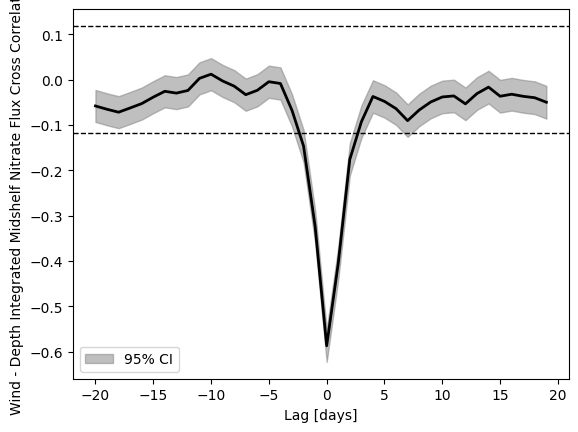

np.float64(-0.5868664772839842)

In [6]:
tdelay = np.arange(-20, 20)
flux_wind_lag_correlation, confint, n = lagged_correlation(
    velocity_flux["nitrate_flux_depth_integrated"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    flux_wind_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind - Depth Integrated Midshelf Nitrate Flux Cross Correlation",
)

flux_wind_lag_correlation.min()

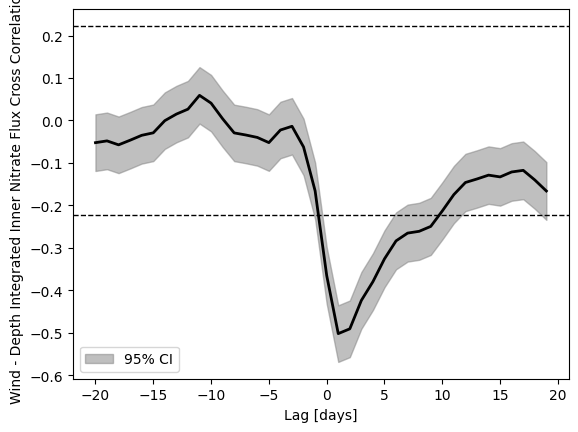

np.float64(-0.5015648073892194)

In [7]:
tdelay = np.arange(-20, 20)
flux_wind_lag_correlation, confint, n = lagged_correlation(
    inner_nitrate["depth_integrated_nitrate"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    flux_wind_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind - Depth Integrated Inner Nitrate Flux Cross Correlation",
)

flux_wind_lag_correlation.min()

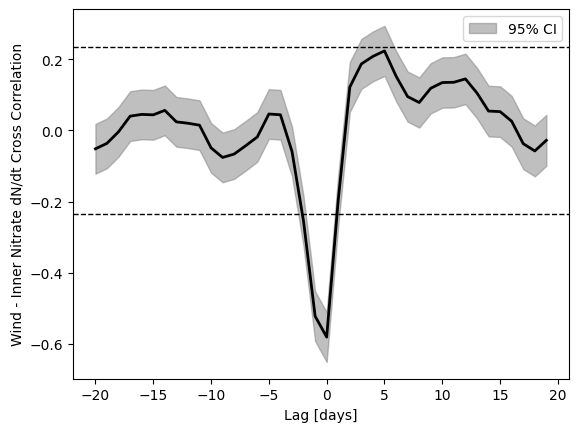

np.float64(-0.5803719473491453)

In [8]:
tdelay = np.arange(-20, 20)
flux_wind_lag_correlation, confint, n = lagged_correlation(
    inner_nitrate["dndt"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    flux_wind_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind - Inner Nitrate dN/dt Cross Correlation",
)

flux_wind_lag_correlation.min()

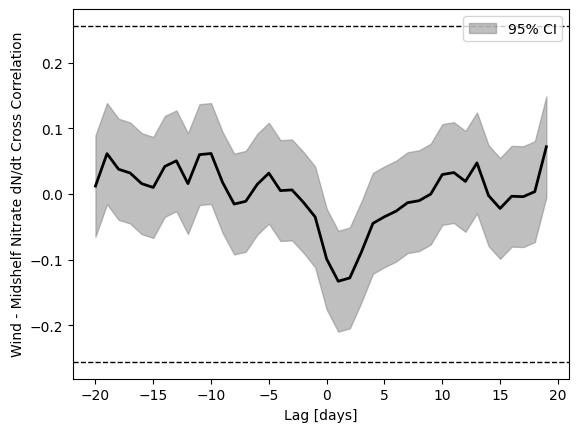

np.float64(-0.13291003463436413)

In [9]:
tdelay = np.arange(-20, 20)
flux_wind_lag_correlation, confint, n = lagged_correlation(
    midshelf_nitrate["dndt"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    flux_wind_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind - Midshelf Nitrate dN/dt Cross Correlation",
)

flux_wind_lag_correlation.min()

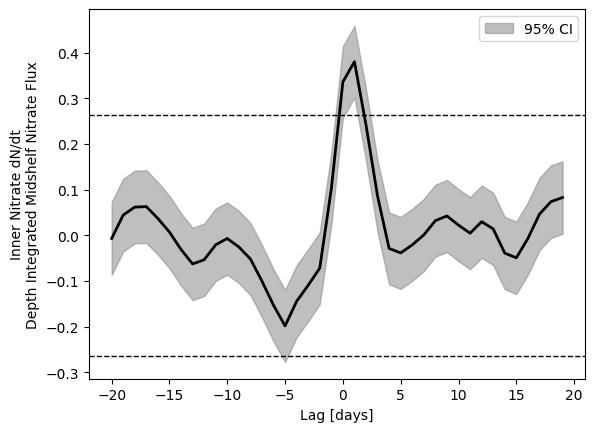

In [10]:
temp_flux, temp_inner, temp_mid = xr.align(
    velocity_flux["nitrate_flux_depth_integrated"],
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)

flux_nitrate_lag_correlation, confint, n = lagged_correlation(
    temp_flux, (temp_inner.dndt * 7000 / 2), tdelay
)

plot_correlations(
    tdelay,
    flux_nitrate_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Inner Nitrate dN/dt\nDepth Integrated Midshelf Nitrate Flux",
)

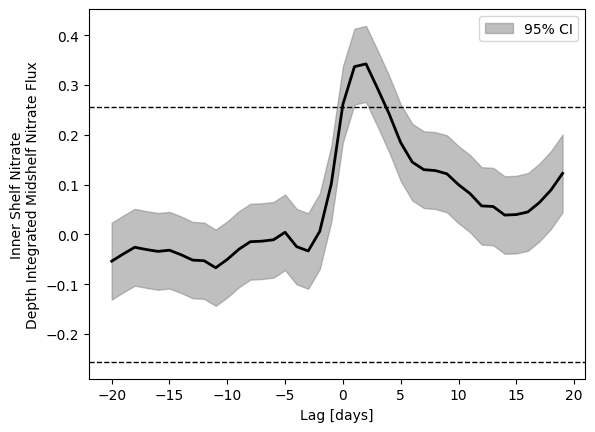

In [11]:
flux_nitrate_lag_correlation, confint, n = lagged_correlation(
    inner_nitrate["nitrate"].mean(dim="depth"),
    velocity_flux["nitrate_flux_depth_integrated"],
    tdelay,
)

plot_correlations(
    tdelay,
    flux_nitrate_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Inner Shelf Nitrate\nDepth Integrated Midshelf Nitrate Flux",
)

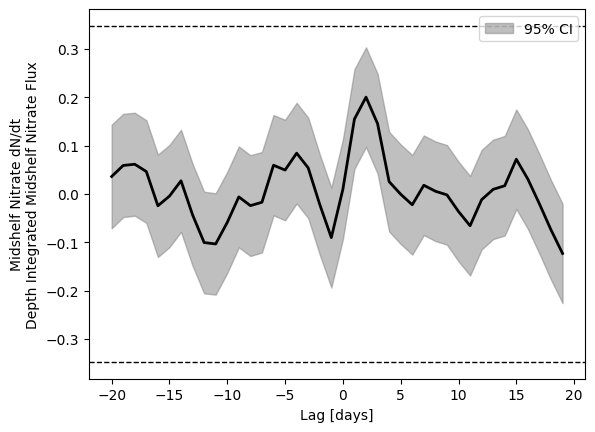

np.float64(0.2001238844578998)

In [12]:
tdelay = np.arange(-20, 20)
flux_dndt_lag_correlation, confint, n = lagged_correlation(
    midshelf_nitrate.dndt, velocity_flux.nitrate_flux_depth_integrated, tdelay
)

plot_correlations(
    tdelay,
    flux_dndt_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Midshelf Nitrate dN/dt\nDepth Integrated Midshelf Nitrate Flux",
)
flux_dndt_lag_correlation.max()

In [13]:
# calculate midshelf flux by interpolating nan and filling ends with constant extrapolation, only for profiles with more than 40 depth points
midshelf_nitrate_interp = xr.concat(
    [
        yi.interpolate_na(
            "depth", fill_value=[yi.dropna("depth")[0], yi.dropna("depth")[-1]]
        )
        for yi in midshelf_nitrate.nitrate
        if yi.dropna("depth").size > 40
    ],
    "time",
)
cs_al_midnitr, midnitr_al_cs = xr.align(
    velocity.cs.dropna("time", how="all"), midshelf_nitrate_interp
)
midshelf_nitrate_flux_depth_integrated = xr.apply_ufunc(
    lambda x, y: np.array(
        [np.trapezoid(yi[~np.isnan(yi)], x[~np.isnan(yi)]) for yi in y]
    ),
    cs_al_midnitr.depth.values,
    (cs_al_midnitr * midnitr_al_cs).values,
)
midshelf_nitrate_flux_depth_integrated = xr.DataArray(
    midshelf_nitrate_flux_depth_integrated, {"time": cs_al_midnitr.time}
)

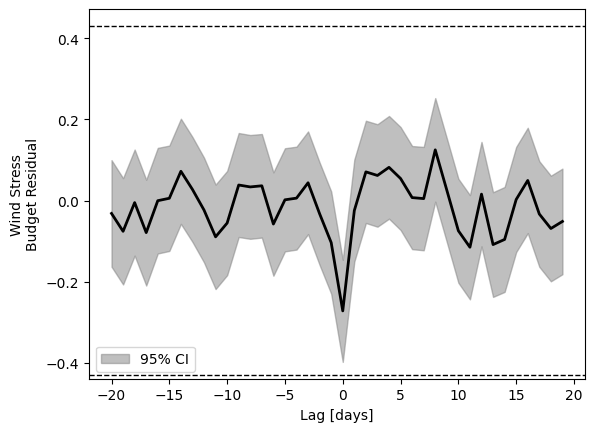

In [14]:
temp_flux, temp_inner, temp_mid = xr.align(
    midshelf_nitrate_flux_depth_integrated,
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)
tdelay = np.arange(-20, 20)
flux_dndt_lag_correlation, confint, n = lagged_correlation(
    wind.coare_y,
    (temp_flux - temp_inner.dndt * 7000 / 2 - temp_mid.dndt * 13000 / 2),
    tdelay,
)

plot_correlations(
    tdelay,
    flux_dndt_lag_correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind Stress\nBudget Residual",
)

In [15]:
midshelf_nitrate_flux_depth_integrated = (
    midshelf_nitrate_flux_depth_integrated.resample(time="1D").mean()
)

In [16]:
# correlation between nitrate flux calculated using in situ vs monthly mean mid shelf nitrate
temp_flux, temp_monthly_flux = xr.align(
    velocity_flux.nitrate_flux_depth_integrated,
    midshelf_nitrate_flux_depth_integrated,
)
mask = ~np.isnan(temp_flux) & ~np.isnan(temp_monthly_flux)
np.corrcoef(temp_flux[mask], temp_monthly_flux[mask])

array([[1.        , 0.90348816],
       [0.90348816, 1.        ]])

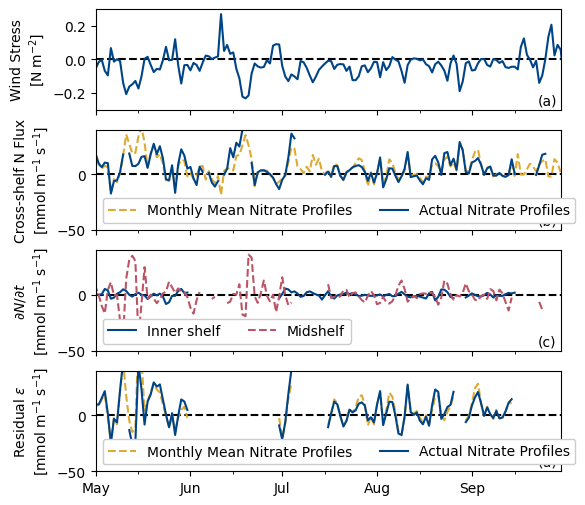

In [17]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(6, 6))
# fig.suptitle("2021 Wind and Nitrate Budget Time Series", fontsize=20)
axs[0].set_xlim(np.datetime64("2021-05-01"), np.datetime64("2021-09-30"))

# [axs[0].axvline(cw.time.values[5], color='gray') for cw in composite_wind_events]
# [axs[1].axvline(cw.time.values[5], color='gray') for cw in composite_wind_events]
# [axs[2].axvline(cw.time.values[5], color='gray') for cw in composite_wind_events]
# [axs[3].axvline(cw.time.values[5], color='gray') for cw in composite_wind_events]
# [ax.tick_params(axis="both", width=3, size=7, labelsize=16) for ax in axs]
# [ax.tick_params(axis="both", which="minor", width=2, size=5) for ax in axs]

# for axis in ["top", "bottom", "left", "right"]:
#     [ax.spines[axis].set_linewidth(3) for ax in axs]

# [ax.minorticks_off() for ax in axs]

axs[0].axhline(0, ls="--", color="black")
axs[0].plot(wind["time"], wind["coare_y"], color="#004488")
axs[0].set_ylim(-0.3, 0.3)
axs[0].set_ylabel("Wind Stress\n[$\\mathsf{N \\; m^{-2}}$]")


axs[1].axhline(0, ls="--", color="black")
axs[1].plot(
    velocity_flux["time"],
    velocity_flux["nitrate_flux_depth_integrated"],
    label="Monthly Mean Nitrate Profiles",
    color="#DDAA33",
    ls="--",
)
axs[1].plot(
    midshelf_nitrate_flux_depth_integrated["time"],
    midshelf_nitrate_flux_depth_integrated,
    label="Actual Nitrate Profiles",
    color="#004488",
)
axs[1].set_ylim(-50, 40)
axs[1].set_ylabel("Cross-shelf N Flux\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[1].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")


axs[2].axhline(0, ls="--", color="black")
axs[2].plot(
    inner_nitrate.time,
    inner_nitrate.dndt * 7000 / 2,
    color="#004488",
    label="Inner shelf",
)
axs[2].plot(
    midshelf_nitrate.time,
    midshelf_nitrate.dndt * 13000 / 2,
    c="#BB5566",
    label="Midshelf",
    ls="--",
)
axs[2].set_ylim(-50, 40)
axs[2].set_ylabel("$\\partial N/\\partial t$\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[2].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")


axs[3].axhline(0, ls="--", color="black")
temp_flux, temp_inner, temp_mid = xr.align(
    velocity_flux.nitrate_flux_depth_integrated,
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)
axs[3].plot(
    temp_flux.time,
    (temp_flux - temp_inner.dndt * 7000 / 2 - temp_mid.dndt * 13000 / 2),
    label="Monthly Mean Nitrate Profiles",
    color="#DDAA33",
    ls="--",
)
temp_flux, temp_inner, temp_mid = xr.align(
    midshelf_nitrate_flux_depth_integrated,
    inner_nitrate.dropna("depth", how="all"),
    midshelf_nitrate.dropna("depth", how="all"),
)
axs[3].plot(
    temp_flux.time,
    (temp_flux - temp_inner.dndt * 7000 / 2 - temp_mid.dndt * 13000 / 2),
    label="Actual Nitrate Profiles",
    color="#004488",
)
axs[3].set_ylim(-50, 40)
axs[3].set_ylabel("Residual $\\epsilon$\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[3].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")
axs[3].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axs[3].xaxis.set_major_locator(mdates.MonthLocator())
axs[3].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))


axs[0].annotate("(a)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[1].annotate("(b)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[2].annotate("(c)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[3].annotate("(d)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
# axs[3].tick_params(axis='x', which='major', labelsize=10)

plt.savefig(
    FIGURES_DIR / "manuscript/2021_nbudget.pdf",
    format="pdf",
    bbox_inches="tight",
)

In [18]:
np.nanmedian(temp_flux - temp_inner.dndt * 7000 / 2 - temp_mid.dndt * 13000 / 2)

np.float64(2.6482174238347915)